In [19]:
# 1 Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
# Extra powerful model
from xgboost import XGBRegressor

# 2
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("First 5 rows of dataset:")
display(df.head())


First 5 rows of dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [22]:
print("\nDataset Description:")
display(df.describe())


Dataset Description:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
# 3️⃣ Feature Engineering
# ------------------------------------------
df["Rooms_per_Person"] = df["AveRooms"] / df["Population"]
df["Bedrooms_per_Room"] = df["AveBedrms"] / df["AveRooms"]
df["Population_per_Household"] = df["Population"] / df["AveOccup"]


In [24]:
# 4️⃣ Split Features and Target
# ------------------------------------------
X = df.drop("MedHouseVal", axis=1)  # Features
y = df["MedHouseVal"]               # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# ------------------------------------------
# 5️⃣ Feature Scaling
# ------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
# ------------------------------------------
# 6️⃣ Train Linear Regression (Baseline)
# ------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\nLinear Regression Results:\nRMSE: {rmse_lr:.4f}\nR² Score: {r2_lr:.4f}")


Linear Regression Results:
RMSE: 0.6955
R² Score: 0.6309


In [13]:
# ------------------------------------------
# 7️⃣ Train Random Forest
# ------------------------------------------
rf_model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results:\nRMSE: {rmse_rf:.4f}\nR² Score: {r2_rf:.4f}")



Random Forest Results:
RMSE: 0.5059
R² Score: 0.8047


In [26]:
# ------------------------------------------
# 8️⃣ Train XGBoost (Best Accuracy)
# ------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Results:\nRMSE: {rmse_xgb:.4f}\nR² Score: {r2_xgb:.4f}")



XGBoost Results:
RMSE: 0.4472
R² Score: 0.8474


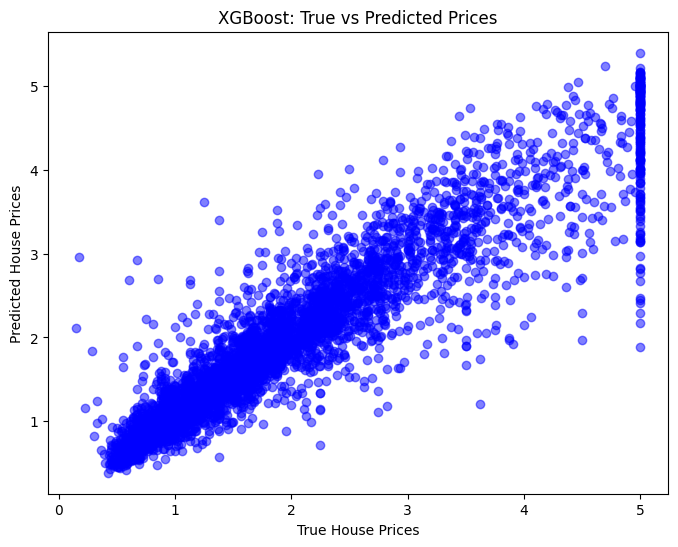

In [27]:
# ------------------------------------------
# 9️⃣ Plot True vs Predicted (XGBoost)
# ------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='blue')
plt.xlabel("True House Prices")
plt.ylabel("Predicted House Prices")
plt.title("XGBoost: True vs Predicted Prices")
plt.show()

In [29]:
# 10 Save model for Streamlit
with open("housing_model12.pkl", "wb") as f:
    pickle.dump({"model": xgb_model, "scaler": scaler, "features": list(X.columns)}, f)

print("✅ Model saved as housing_model1.pkl")

✅ Model saved as housing_model1.pkl
